# 1.3 Build a 4-qubit chip

In [1.1 Quick start](./1.1-Quick-start.ipynb) you placed a transmon, wired two with a CPW, and got comfortable with the `option → rebuild → view` loop. Now we'll scale up.

You'll build a four-qubit chip with:

- 4 `TransmonPocket` qubits arranged in a ring at the cardinal directions.
- 4 `RouteMeander` CPWs connecting neighbouring qubits via their pins.
- Shared `design.variables` for CPW width and gap so a single change updates every component.
- An overlap-check pass before exporting.

By the end you'll have a full design ready to save with `to_python_script()` (covered next in [1.4 Saving & exporting](./1.4-Saving-Your-Chip-Design.ipynb)).


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/tutorials/1%20Overview/1.3%20Build%20a%204-qubit%20chip.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=tutorials%2F1%20Overview%2F1.3%20Build%20a%204-qubit%20chip.ipynb)

> 💡 **Running in Colab or Binder?** Skip the desktop GUI install — the cell below grabs the lite (no-Qt) wheel, and `qm.gui(design)` auto-picks an inline matplotlib viewer with the same API as the desktop `MetalGUI`.

In [1]:
# In Colab / Binder, uncomment to install Quantum Metal (lite, no Qt).
# Locally you should already have it via `pip install quantum-metal` or
# `pip install 'quantum-metal[gui]'` for the desktop GUI.
# !pip install -q quantum-metal

In [2]:
import qiskit_metal as metal
import qiskit_metal as qm
from qiskit_metal import Dict, designs, draw
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

design = designs.DesignPlanar()
design.overwrite_enabled = True  # we'll re-run cells freely
gui = qm.gui(design)

# Dark theme for the desktop GUI screenshots below. Guarded because the
# inline headless viewer used on Colab/Binder has no stylesheet concept.
if hasattr(gui, "load_stylesheet"):
    gui.load_stylesheet("metal_dark")

04:11PM 21s WARNING [check_lengths]: For path table, component=cpw4, key=trace has short segments that could cause issues with fillet. Values in (19-20)  are index(es) in shapely geometry.
04:11PM 21s WARNING [check_lengths]: For path table, component=cpw4, key=cut has short segments that could cause issues with fillet. Values in (19-20)  are index(es) in shapely geometry.


In [3]:
%metal_heading My first quantum chip

## A whole chip — four qubits + couplers

Now scale up: drop four ``TransmonPocket`` qubits, then connect them with ``RouteMeander`` CPWs. First, clear the design.

In [4]:
design.delete_all_components()
gui.rebuild()  # refresh

In [5]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# Allow running the same cell here multiple times to overwrite changes
design.overwrite_enabled = True

## Custom options for all the transmons
options = dict(
    # Some options we want to modify from the defaults
    # (see below for defaults)
    pad_width="425 um",
    pocket_height="650um",
    # Use FakeJunction_01 from resources/Fake_Junctions.GDS for all qubits.
    gds_cell_name="FakeJunction_01",
    # Adding 4 connectors (see below for defaults)
    connection_pads=dict(
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

## Create 4 transmons

q1 = TransmonPocket(
    design, "Q1", options=dict(pos_x="+2.55mm", pos_y="+0.0mm", **options)
)
q2 = TransmonPocket(
    design,
    "Q2",
    options=dict(pos_x="+0.0mm", pos_y="-0.9mm", orientation="90", **options),
)
q3 = TransmonPocket(
    design, "Q3", options=dict(pos_x="-2.55mm", pos_y="+0.0mm", **options)
)
q4 = TransmonPocket(
    design,
    "Q4",
    options=dict(pos_x="+0.0mm", pos_y="+0.9mm", orientation="90", **options),
)

## Rebuild the design
gui.rebuild()
gui.autoscale()

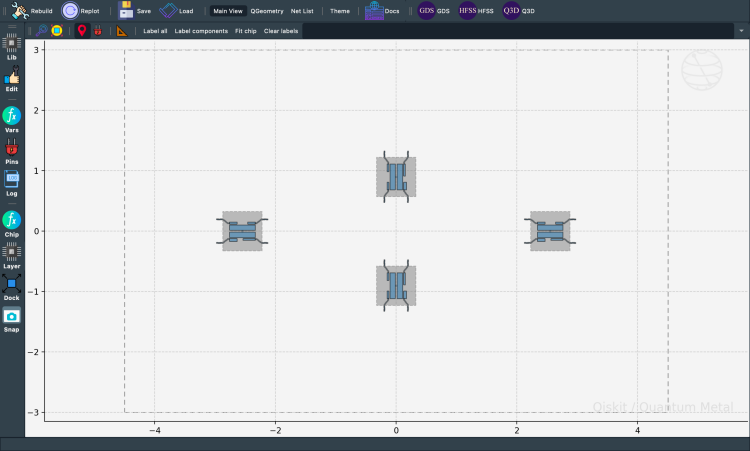

In [6]:
gui.toggle_docks(True)
gui.screenshot()

### Try the GUI keyboard shortcuts

If you're running this locally with the desktop GUI open, try these on
`Q1`:

- **Click** it to select, then the **arrow keys** to nudge it (Shift for a
  coarser step, Alt for a finer one).
- **Q** / **E** (also `[` / `]`) to rotate it 90° at a time; hold **Shift**
  for a 15° step.
- **R** to rebuild, **double-click** a component (or click one that's
  already selected) to open its Edit panel.

Press **?** in the GUI, or use the Help button on the plot toolbar, for the
full reference -- also written up in the docs under **How It Works → GUI
Navigation & Shortcuts**.

In [7]:
%metal_heading Connecting QPins with coplanar waveguides (CPWs)

### Connecting QPins with coplanar waveguides

``RouteMeander`` is the meandered CPW component. Inspect its template options:

In [8]:
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

Now wire all four qubits in a ring. The repetition is wrapped in a small helper for clarity.

In [9]:
options = Dict(meander=Dict(lead_start="0.1mm", lead_end="0.1mm", asymmetry="0 um"))


def connect(
    component_name: str,
    component1: str,
    pin1: str,
    component2: str,
    pin2: str,
    length: str,
    asymmetry="0 um",
    flip=False,
):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(component=component1, pin=pin1),
            end_pin=Dict(component=component2, pin=pin2),
        ),
        lead=Dict(start_straight="0.13mm"),
        total_length=length,
        fillet="90um",
    )
    myoptions.update(options)
    myoptions.meander.asymmetry = asymmetry
    myoptions.meander.lead_direction_inverted = "true" if flip else "false"
    return RouteMeander(design, component_name, myoptions)


asym = 150
cpw1 = connect("cpw1", "Q1", "d", "Q2", "c", "6.0 mm", f"+{asym}um")
cpw2 = connect("cpw2", "Q3", "c", "Q2", "a", "6.1 mm", f"-{asym}um", flip=True)
cpw3 = connect("cpw3", "Q3", "a", "Q4", "b", "6.0 mm", f"+{asym}um")
cpw4 = connect("cpw4", "Q1", "b", "Q4", "d", "6.1 mm", f"-{asym}um", flip=True)

gui.rebuild()
gui.autoscale()

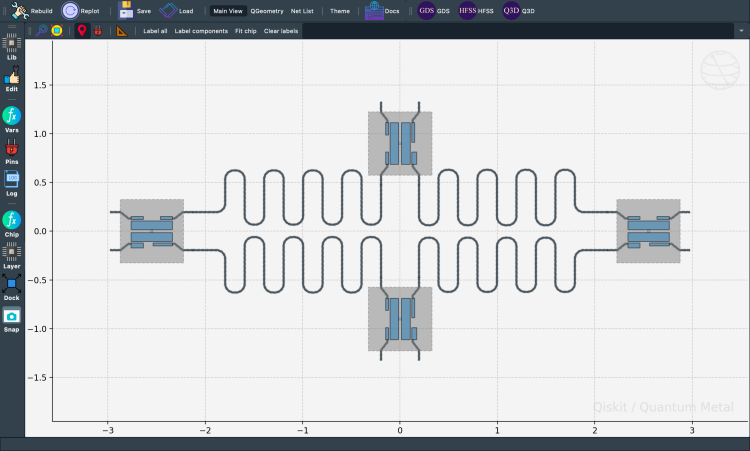

In [10]:
gui.toggle_docks(True)
gui.screenshot()

In [11]:
design.components.keys()

['Q1', 'Q2', 'Q3', 'Q4', 'cpw1', 'cpw2', 'cpw3', 'cpw4']

Access the resulting CPW from the design:

In [12]:
design.components.cpw2

name:    cpw2
class:   RouteMeander          
options: 
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'pin_inputs'        : {
       'start_pin'         : {
            'component'         : 'Q3',                         
            'pin'               : 'c',                          
                             },
       'end_pin'           : {
            'component'         : 'Q2',                         
            'pin'               : 'a',                          
                             },
                        },
  'fillet'            : '90um',                       
  'lead'              : {
       'start_straight'    : '0.13mm',                     
       'end_straight'      : '0mm',                        
       'start_jogged_extension': '',                           
       'end_jogged_extension': '',                           
                        },
  'total_length'      : '6.1 mm',        

Inspect every pin in the design:

In [13]:
%metal_heading Variables in options

## Design variables

Designs carry a ``variables`` dict. Components can reference these by name in their option strings — change a variable, every dependent component updates on the next ``rebuild()``.

In [14]:
design.variables.cpw_width = "10um"
design.variables.cpw_gap = "6um"
gui.rebuild()

Use variables to share values across components:

In [15]:
cpw1.options.lead.end_straight = "100um"
cpw2.options.lead.end_straight = "100um"
cpw3.options.lead.end_straight = "100um"
cpw4.options.lead.end_straight = "100um"

In [16]:
# Set variables in the design
design.variables.pad_width = "450 um"
design.variables.cpw_width = "25 um"
design.variables.cpw_gap = "12 um"

# Assign variables to component options
q1.options.pad_width = "pad_width"
q2.options.pad_width = "pad_width"
q3.options.pad_width = "pad_width"
q4.options.pad_width = "pad_width"

# Rebuild all components and refresh the gui
gui.rebuild()
gui.autoscale()

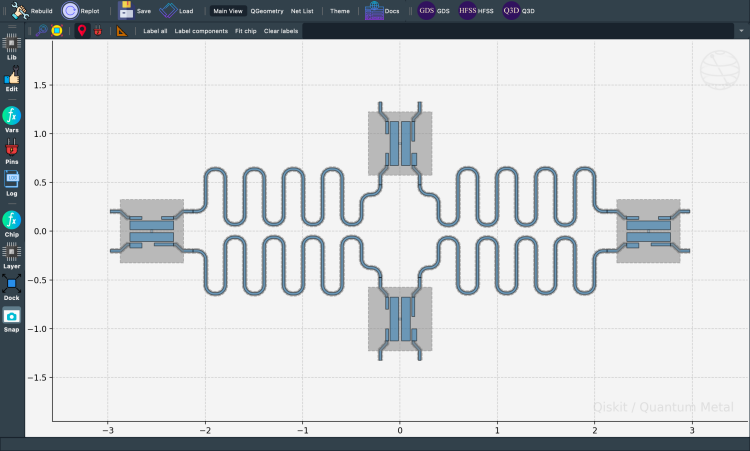

In [17]:
gui.screenshot()

## Before you export — check for overlaps

On complex chips with many components, accidental geometry overlaps can cause
DRC errors at the fab. Metal ships a built-in design-rule checker:

See the quick-topic notebook **[Testing QComponents for overlap and collisions](../quick-topics/Testing-QComponents-for-overlap-and-collisions.ipynb)** for more on the individual rules, including `MetalOverlapRule`.

In [ ]:
# Run design-rule checking (DRC) on the current design. validate() returns
# a ValidationResult -- truthy iff no ERROR-severity findings, iterable
# over Finding objects, with a readable .report().
from qiskit_metal.validation import validate

result = validate(design)
print(result.report())

In [19]:
%metal_heading Qiskit Metal Version

In [20]:
metal.about();


Qiskit Metal        0.8.0

Basic
____________________________________
 Python              3.11.14 (main, Dec  5 2025, 21:28:33) [Clang 21.1.4 ]
 Platform            Darwin arm64
 Installation path   /Users/zlatkominev/CODE_REPOS/quantum_hardware_all/qiskit-metal/src/qiskit_metal

Packages
____________________________________
 Numpy               1.26.4
 Qutip               5.2.2

Rendering
____________________________________
 Matplotlib          3.10.8

GUI
____________________________________
 PySide6 version     6.10.1
 Qt version          6.10.1
 SIP version         Not installed

IBM Quantum Team


Close the GUI window:

In [ ]:
# gui.main_window.close()

---

## What's next?

- **Save your design**: [1.4 Saving & exporting](./1.4-Saving-Your-Chip-Design.ipynb) — `to_python_script()` for reproducibility + GDS export for fabrication.
- **Sweep parameters**: [1.5 Parametric design](./1.5-Parametric-design---iterate-and-compare.ipynb) — compare design variants side by side.
- **Custom components**: [2.31 Create a QComponent — Basic](../2-From-components-to-chip/2.31-Create-a-QComponent-Basic.ipynb).
- **Routing options**: [2.11 Routing 101](../2-From-components-to-chip/2.11-Routing-101.ipynb) for routing techniques beyond `RouteMeander`.
